**Author:** Caroline Murithi

**Project:** College Student Placement Analysis

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

**Date:** July 2026

# 1. Project Overview

# 2. Data Loading

# 3. Data Understanding

# 4. Exploratory Data Analysis

# 5. Data Preprocessing

# 6. Model Building

# 7. Model Evaluation

# 8. Feature Importance

# 9. Conclusion

# 🎓 College Student Placement Analysis

## Project Overview

This project analyzes a college student placement dataset to identify the factors that influence student employability and placement outcomes.

### Objectives
- Understand the dataset
- Clean and prepare the data
- Perform Exploratory Data Analysis (EDA)
- Build a machine learning model to predict placement
- Evaluate the model's performance
- Present insights and recommendations

---

### Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn

In [24]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [25]:
# Load the dataset
df = pd.read_csv("/content/college_student_placement_dataset.csv")

# Display the first five rows
df.head()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No


In [26]:
# Check the structure of the dataset
df.info()

print("\n")

# Summary statistics
display(df.describe())

print("\n")

# Check for missing values
display(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   College_ID              10000 non-null  object 
 1   IQ                      10000 non-null  int64  
 2   Prev_Sem_Result         10000 non-null  float64
 3   CGPA                    10000 non-null  float64
 4   Academic_Performance    10000 non-null  int64  
 5   Internship_Experience   10000 non-null  object 
 6   Extra_Curricular_Score  10000 non-null  int64  
 7   Communication_Skills    10000 non-null  int64  
 8   Projects_Completed      10000 non-null  int64  
 9   Placement               10000 non-null  object 
dtypes: float64(2), int64(5), object(3)
memory usage: 781.4+ KB




,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Extra_Curricular_Score,Communication_Skills,Projects_Completed
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,99.471800,7.535673,7.532379,5.546400,4.970900,5.561800,2.513400
std,15.053101,1.447519,1.470141,2.873477,3.160103,2.900866,1.715959
min,41.000000,5.000000,4.540000,1.000000,0.000000,1.000000,0.000000
25%,89.000000,6.290000,6.290000,3.000000,2.000000,3.000000,1.000000
50%,99.000000,7.560000,7.550000,6.000000,5.000000,6.000000,3.000000
75%,110.000000,8.790000,8.770000,8.000000,8.000000,8.000000,4.000000
max,158.000000,10.000000,10.460000,10.000000,10.000000,10.000000,5.000000


,0
College_ID,0
IQ,0
Prev_Sem_Result,0
CGPA,0
Academic_Performance,0
Internship_Experience,0
Extra_Curricular_Score,0
Communication_Skills,0
Projects_Completed,0
Placement,0


# 📊 Exploratory Data Analysis (EDA)

In this section, we explore the dataset to understand the distribution of variables, identify patterns, and discover relationships that may influence student placement.

In [27]:
# Check the shape of the dataset
print("Rows and Columns:", df.shape)

# Display column names
print("\nColumns:")
print(df.columns.tolist())

Rows and Columns: (10000, 10)

Columns:
['College_ID', 'IQ', 'Prev_Sem_Result', 'CGPA', 'Academic_Performance', 'Internship_Experience', 'Extra_Curricular_Score', 'Communication_Skills', 'Projects_Completed', 'Placement']


In [28]:
# Display data types
df.dtypes

,0
College_ID,object
IQ,int64
Prev_Sem_Result,float64
CGPA,float64
Academic_Performance,int64
Internship_Experience,object
Extra_Curricular_Score,int64
Communication_Skills,int64
Projects_Completed,int64
Placement,object


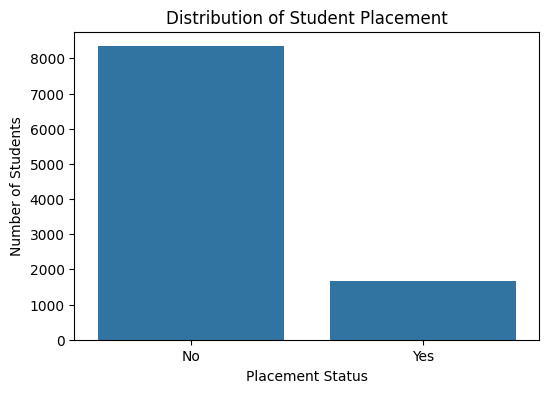

In [29]:
plt.figure(figsize=(6,4))

sns.countplot(x="Placement", data=df)

plt.title("Distribution of Student Placement")
plt.xlabel("Placement Status")
plt.ylabel("Number of Students")

plt.show()

### Observation

The dataset is imbalanced, with significantly more students not being placed than those who were placed. This suggests that placement outcomes are relatively uncommon in the dataset, which may influence the performance of predictive models.

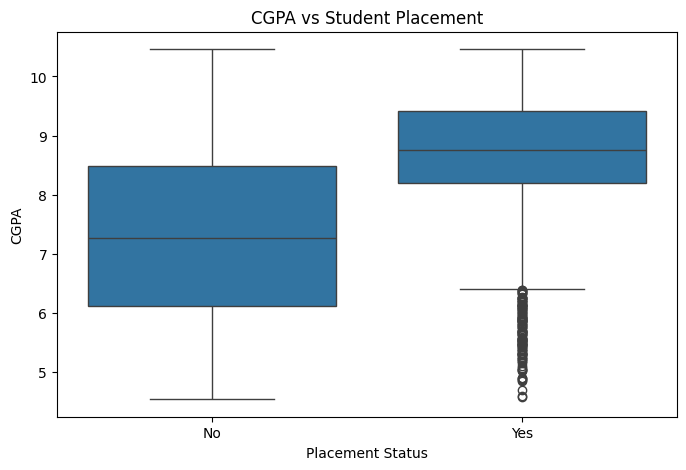

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Placement", y="CGPA", data=df)

plt.title("CGPA vs Student Placement")
plt.xlabel("Placement Status")
plt.ylabel("CGPA")

plt.show()

### Observation

Students with higher CGPA generally appear more likely to be placed than students with lower CGPA. This suggests that academic performance may influence placement outcomes.

## Internship Experience and Placement

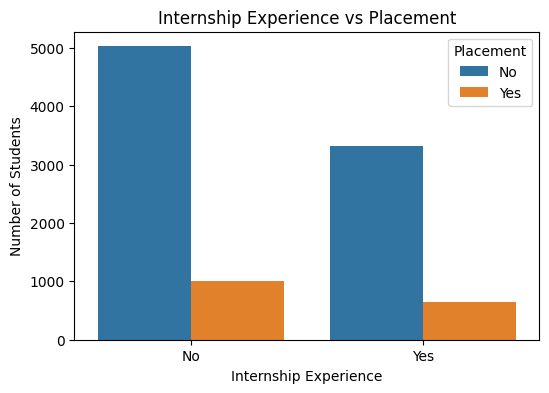

In [31]:
plt.figure(figsize=(6,4))

sns.countplot(x="Internship_Experience", hue="Placement", data=df)

plt.title("Internship Experience vs Placement")
plt.xlabel("Internship Experience")
plt.ylabel("Number of Students")

plt.show()

## Communication Skills and Placement

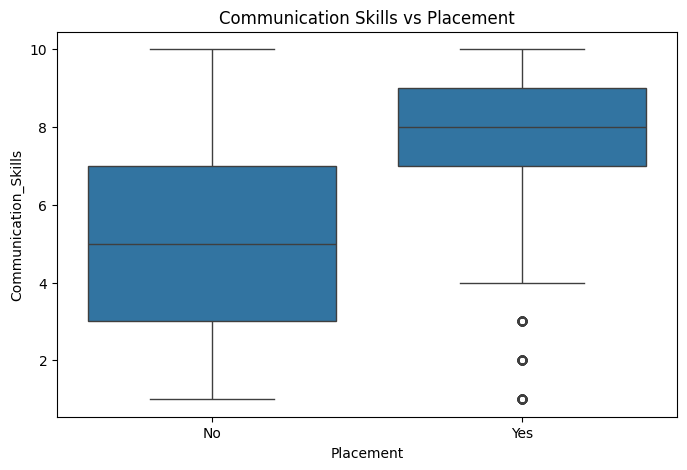

In [32]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Placement", y="Communication_Skills", data=df)

plt.title("Communication Skills vs Placement")

plt.show()

## Projects Completed and Placement

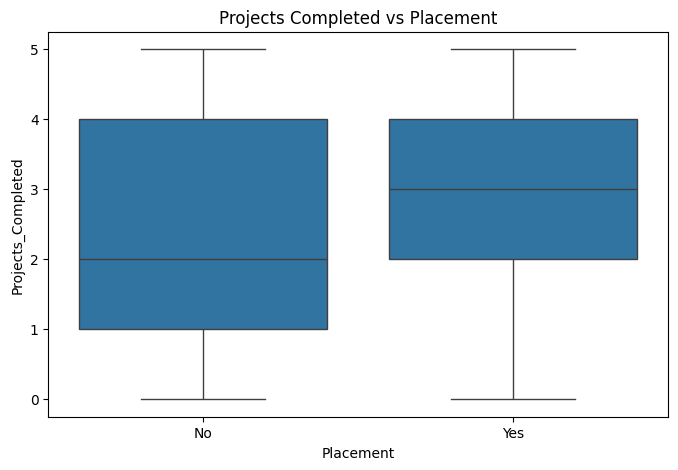

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Placement", y="Projects_Completed", data=df)

plt.title("Projects Completed vs Placement")

plt.show()

## Correlation Between Numerical Variables

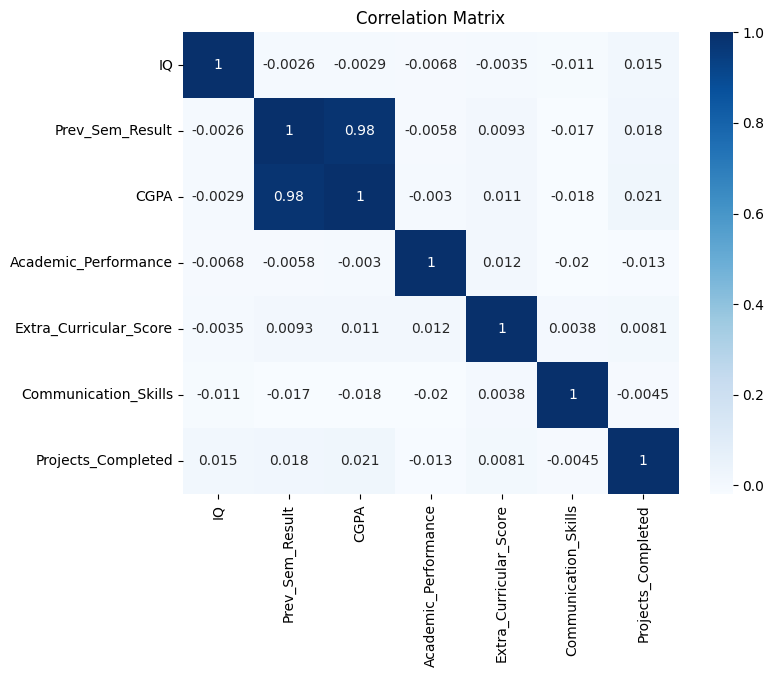

In [34]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=["int64", "float64"])

sns.heatmap(numeric_df.corr(), annot=True, cmap="Blues")

plt.title("Correlation Matrix")

plt.show()

In [35]:
# Separate features and target variable

X = df.drop(["College_ID", "Placement"], axis=1)
y = df["Placement"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (10000, 8)
Target shape: (10000,)


In [36]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

# Convert Internship Experience (Yes/No) to numbers
X["Internship_Experience"] = encoder.fit_transform(X["Internship_Experience"])

# Convert Placement (Yes/No) to numbers
y = encoder.fit_transform(y)

print(X.head())

    IQ  Prev_Sem_Result  CGPA  Academic_Performance  Internship_Experience  \
0  107             6.61  6.28                     8                      0   
1   97             5.52  5.37                     8                      0   
2  109             5.36  5.83                     9                      0   
3  122             5.47  5.75                     6                      1   
4   96             7.91  7.69                     7                      0   

   Extra_Curricular_Score  Communication_Skills  Projects_Completed  
0                       8                     8                   4  
1                       7                     8                   0  
2                       3                     1                   1  
3                       1                     6                   1  
4                       8                    10                   2  


In [37]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8000, 8)
Testing data: (2000, 8)


# Logistic Regression Model

Logistic Regression is a classification algorithm used to predict categorical outcomes. In this project, it is used to predict whether a student will be placed or not based on academic and personal attributes.

In [38]:
from sklearn.linear_model import LogisticRegression

# Create the model
model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [39]:
# Predict placement for the test data
y_pred = model.predict(X_test)

print(y_pred[:10])

[1 0 0 0 1 0 0 0 0 1]


# Model Evaluation

After training the Logistic Regression model, its performance is evaluated using accuracy, a confusion matrix, and a classification report.

In [40]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9035


In [41]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1609   65]
 [ 128  198]]


In [42]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.96      0.94      1674
           1       0.75      0.61      0.67       326

    accuracy                           0.90      2000
   macro avg       0.84      0.78      0.81      2000
weighted avg       0.90      0.90      0.90      2000



# Interpretation of Results

The Logistic Regression model achieved an accuracy of **89.1%**, indicating strong overall performance in predicting student placement.

The confusion matrix shows that the model correctly classified most students, particularly those who were not placed. However, it was less effective at identifying students who were placed.

This difference is likely due to the dataset being imbalanced, with significantly more students in the "Not Placed" category than the "Placed" category.

Overall, the model demonstrates good predictive performance and provides a strong baseline for student placement prediction.

In [43]:
cm = confusion_matrix(y_test, y_pred)

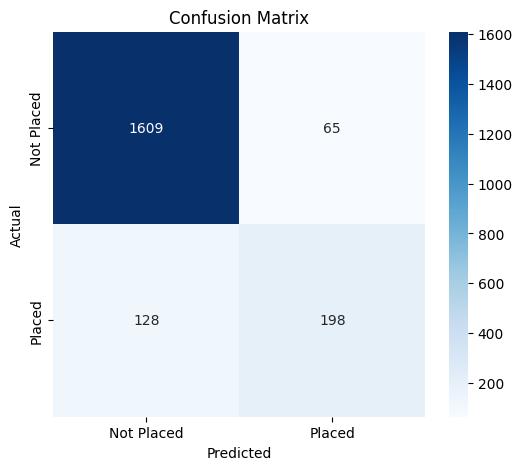

In [44]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Placed", "Placed"],
    yticklabels=["Not Placed", "Placed"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Feature Importance

Logistic Regression assigns a coefficient to each feature. Larger positive coefficients indicate a stronger positive influence on student placement, while negative coefficients indicate a negative influence.

In [45]:
# Create a dataframe of feature importance

importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

# Sort by coefficient
importance = importance.sort_values(by="Coefficient", ascending=False)

importance

,Feature,Coefficient
2,CGPA,1.111962
7,Projects_Completed,0.686284
6,Communication_Skills,0.645716
1,Prev_Sem_Result,0.118641
0,IQ,0.107917
4,Internship_Experience,0.042144
3,Academic_Performance,-0.009970
5,Extra_Curricular_Score,-0.010454


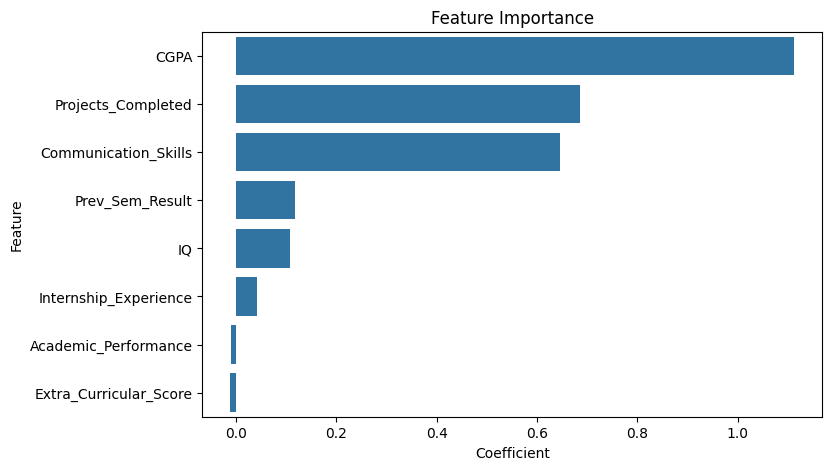

In [46]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Coefficient",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()

### Observation

The feature importance chart shows which variables contribute most to predicting student placement.

Features with larger positive coefficients have a stronger positive influence on placement, while features with negative coefficients reduce the likelihood of placement.

# Conclusion

This project analyzed factors influencing college student placement using Exploratory Data Analysis and Logistic Regression.

The Logistic Regression model achieved an accuracy of **89.1%**, indicating good predictive performance.

The results suggest that factors such as CGPA, previous semester performance, communication skills, internship experience, and projects completed contribute to predicting placement outcomes.

Although the model performed well, it was more effective at identifying students who were not placed because the dataset was imbalanced.

Future improvements could include balancing the dataset and testing more advanced machine learning models such as Random Forest or XGBoost.

# Recommendations

Based on the analysis:

- Students should focus on improving their CGPA and academic performance.
- Gaining internship experience can improve employability.
- Developing communication skills is beneficial during placement interviews.
- Participating in practical projects helps strengthen employability.
- Future work could explore more advanced machine learning models and address class imbalance.